In [9]:
from pathlib import Path
import sys

# making modules in Code avaliable in this folder
# If the kernel is opened from the notebook folder:
project_root = Path.cwd().resolve().parent  # -> /home/.../Project_1

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


from Code.general_functions import make_data, np, design_matrix, FIG_DIR
from Code.resampling_methods import cross_validation, grid_search, bootstrap_resampling, train_through_gridsearchCV, mse_decomposer
import Code.colors as c
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from matplotlib.lines import Line2D
mindegree, maxdegree = 1, 21

degs = np.arange(mindegree, maxdegree)
x_,y_ = make_data()
x_train, x_test, y_train, y_test = train_test_split(x_,y_, test_size=0.2, random_state=2026)


### Testing cross-validation strategies for i)

To asses the bias variance tradeoff one can do resampling. Both bootstrap and kfold resampling was attempted to decompose the MSE. As hyperparameters were trained using the kfold cross validation strategy, kfold resampling was chosen for MSE decompostion estimates. However, to be sure this was the right choice we compared bootstrap and kfold resampling.

In [2]:
# results, model_shorthands = train_through_gridsearchCV(x_, y_, models = ['ridge'], Ks=[5], return_std = True)
results, model_shorthands = train_through_gridsearchCV(x_, y_, models = ['ridge', 'lasso'], Ks=[5,10], return_std = True)

# decomposing mse with both kfold and bootstrap resampling
kfold_resamples = 40
bootstrap_resamples = 50
mse_decomposition_kfold = mse_decomposer(x_,y_, results, model_shorthands, resamples = kfold_resamples)
mse_decomposition_bootstrap  = mse_decomposer(x_,y_, results, model_shorthands, resamples = bootstrap_resamples, method = "bootstrap_resampling")


/home/hmwes/machinelearning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.246840e-03, tolerance: 5.396e-04
  model = cd_fast.enet_coordinate_descent(
/home/hmwes/machinelearning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.715266e-01, tolerance: 6.725e-04
  model = cd_fast.enet_coordinate_descent(
/home/hmwes/machinelearning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

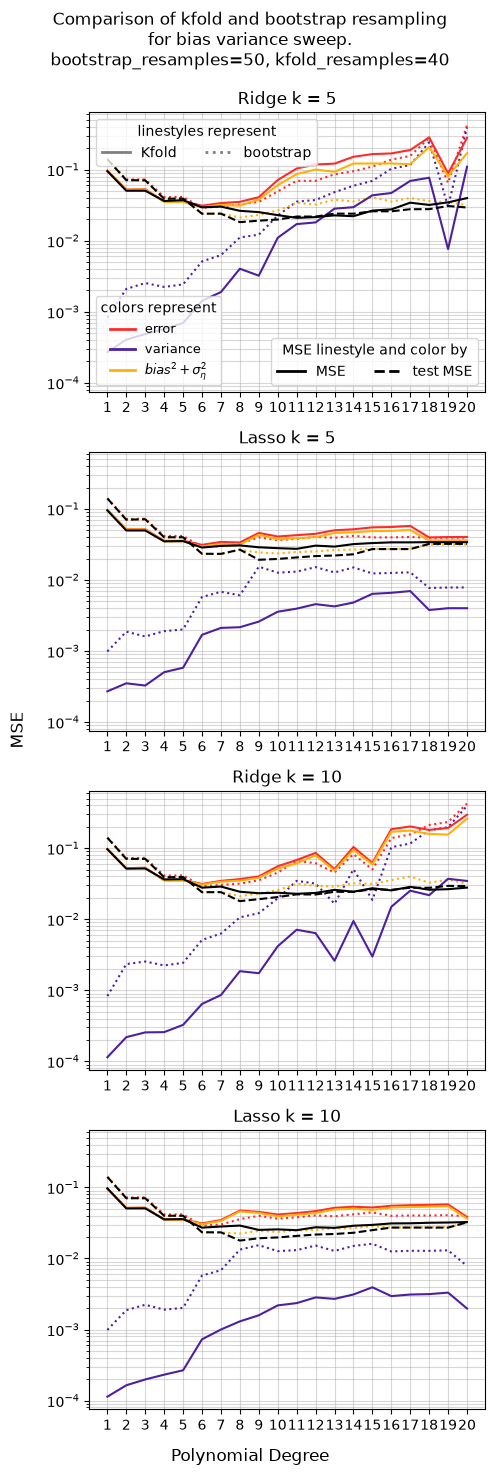

In [17]:

fig, axs = plt.subplots(1*len(model_shorthands),1, figsize = (5,15), sharey = True)   
# fig, axs = plt.subplots(1,1*len(model_shorthands), figsize = (5*len(model_shorthands), 5), sharey = True)   
# fig, axs = plt.subplots(2,2, figsize = (10, 10))   
# axs = axs.flat
colors = c.ERROR, c.BIAS, c.VARIANCE
error_bias_variance = ['error','bias','variance']
for idx, model_shorthand in enumerate(model_shorthands):
        ax = np.atleast_1d(axs)[idx]  # handles the single-Axes case from plt.subplots

        
    
        for i, mse_decomposition in enumerate([mse_decomposition_bootstrap, mse_decomposition_kfold]):
                model ,_ ,_ ,k = model_shorthand.split()
               

                if i == 0:
                        resamplinglinestyle = "dotted"
                        label = 'bootstrap'
                elif i == 1:
                        resamplinglinestyle = 'solid'
                        label = 'kfold'

                if model == 'ridge':
                        if k == '5':
                                color = c.RIDGE
                        else:
                                color = c.RIDGE2
                elif model == 'lasso':
                        if k == '5':
                                color = c.LASSO
                        else:
                                color = c.LASSO2

                

                
                ax.plot(degs, mse_decomposition[model_shorthand]['error'],
                         color = c.ERROR, linestyle = resamplinglinestyle)
                ax.plot(degs, mse_decomposition[model_shorthand]['variance'],
                         color = c.BIAS, linestyle = resamplinglinestyle)
                ax.plot(degs, mse_decomposition[model_shorthand]['bias2_plus_noise'], 
                         color = c.VARIANCE, linestyle = resamplinglinestyle)
                
                ax.set_yscale("log")
                ax.set_title(model_shorthand)
                ax.set_xticks(degs)
                ax.grid(which="both", alpha=0.5)
                ax.set_title(f"{model.capitalize()} k = {int(k)}" )

        ax.plot(degs, results[model_shorthand]['test_mse'], color = 'black', linestyle = 'dashed',  label = "test MSE")
        ax.plot(degs, results[model_shorthand]['mse'], color = 'black', linestyle = 'solid',  label = "MSE")

        

bias_variance_handels = [
    Line2D([0], [0],  linestyle="solid", color = c.ERROR, linewidth=2, label="error"),
    Line2D([0], [0],  linestyle="solid", color = c.BIAS, linewidth=2, label="variance"),
    Line2D([0], [0],  linestyle="solid", color = c.VARIANCE, linewidth=2, label=r"$bias^2 + \sigma^2_\eta$"),
]


# --- keep MSE/test MSE labels too ---
main_handles = [
    Line2D([0], [0], color="black", linestyle="solid", linewidth=2, label="MSE"),
    Line2D([0], [0], color="black", linestyle="dashed", linewidth=2, label="test MSE"),
]

kfold_bootstrap_handels = [
        Line2D([0], [0], color="grey", linestyle="solid", linewidth=2, label="Kfold"),
        Line2D([0], [0], color="grey", linestyle="dotted", linewidth=2, label="bootstrap"),
]

legend1 = axs[0].legend(
    handles=kfold_bootstrap_handels ,
    loc="upper left",
    frameon=True,
    title = "linestyles represent", 
    ncol=2,
    fontsize=10,
)
axs[0].add_artist(legend1)

legend2 = axs[0].legend(
    handles=main_handles ,
    loc="lower right",
    frameon=True,
    title = "MSE linestyle and color by", 
    ncol=2,
    fontsize=10,
)
axs[0].add_artist(legend2)


legend3 = axs[0].legend(
    handles=bias_variance_handels,
    loc="lower left",
    frameon=True,
    title = "colors represent",
    fontsize=9,
)

fig.suptitle(f"Comparison of kfold and bootstrap resampling\n for bias variance sweep. \n {bootstrap_resamples=}, {kfold_resamples=} \n")
fig.supxlabel("Polynomial Degree").set_in_layout(True)
fig.supylabel("MSE").set_in_layout(True)
fig.tight_layout()
plt.savefig(fname=FIG_DIR/'Part_i_hyperparameters_msedecomposition_kfold_bootstrap.pdf')

Based upon this result, we see that neither model really works for MSE decomposition. We try with different numbers of samples to see if this makes any difference

### Bootstrap MSE decompostion

In [36]:
def plot_mse_decomposition(results, model_shorthands, model_idx, resamples = [10,20,40,60,80,100],  method = 'kfold_resampling', test_wholedataset= False):

    mse_decompositions= {}

    model_shorthand = model_shorthands[model_idx] 
    print(model_shorthand)
    for resample in resamples: 
        mse_decompositions[resample] = mse_decomposer(x_,y_, results, [model_shorthand],
                                                                resamples = resample, method = method, test_wholedataset= test_wholedataset)

    fig, ax = plt.subplots(figsize=(8, 5))


    # --- decomposition lines: color = n resamples, style = term ---
    term_styles = {
        "error": {"ls": "-", "label": "error"},
        "variance": {"ls": "--", "label": "variance"},
        "bias2_plus_noise": {"ls": ":", "label": "bias² + noise"},
    }

    colors = c.broad_range

    model, _, _, k = model_shorthand.split()
    k = int(k)

    for idx, resample in enumerate(resamples):
        color = colors[idx]
        dec = mse_decompositions[resample][model_shorthand]

        for term, meta in term_styles.items():
            ax.plot(
                degs,
                dec[term],
                color=color,
                linestyle=meta["ls"],
                linewidth=1.8,
                alpha=0.9,
            )

    # --- MSE and test MSE (keep as-is) ---
    ax.plot(
        degs,
        results[model_shorthand]["mse"],
        color="black",
        linestyle="solid",
        linewidth=2,
        label="MSE",
    )
    ax.plot(
        degs,
        results[model_shorthand]["test_mse"],
        color="black",
        linestyle="--",
        linewidth=2,
        label="test MSE",
    )

    # --- custom legend for decomposition terms in grey ---
    term_handles = [
        Line2D([0], [0], color="0.35", linestyle="-", linewidth=2, label="error"),
        Line2D([0], [0], color="0.35", linestyle="--", linewidth=2, label="variance"),
        Line2D([0], [0], color="0.35", linestyle=":", linewidth=2, label=r"bias + $\sigma^2_\eta$"),
    ]

    # --- custom legend for resample counts in color ---
    resample_handles = [
        Line2D([0], [0], color=colors[i], linewidth=2, label=f"n = {resamples[i]}")
        for i in range(len(resamples))
    ]

    # --- keep MSE/test MSE labels too ---
    main_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="MSE"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="test MSE"),
    ]

    legend1 = ax.legend(
        handles=main_handles + term_handles,
        loc="upper left",
        frameon=True,
        ncol=2,
        fontsize=10,
    )
    ax.add_artist(legend1)

    legend2 = ax.legend(
        handles=resample_handles,
        loc="lower right",
        frameon=True,
        title="number of resamples",
        fontsize=9,
    )



    ax.set_yscale("log")
    ax.set_xticks(degs)
    ax.grid(which="both", alpha=0.5)

    if test_wholedataset:
        datapartition = 'using all data'
    else:
        datapartition = 'using training data'

    method_ , _ = method.split('_') 

    ax.set_title(f"Comparing n refits with {method_} on {model.capitalize()} \n with {k} folds {datapartition}")
    ax.set_xlabel("Polynomial Degree")
    ax.set_ylabel("MSE")
    plt.tight_layout()
    plt.savefig(fname=FIG_DIR / f"Part_i_hyperparameters_msedecomposition_{method}_clean_test_wholedataset{test_wholedataset}.pdf")

ridge folds = 5


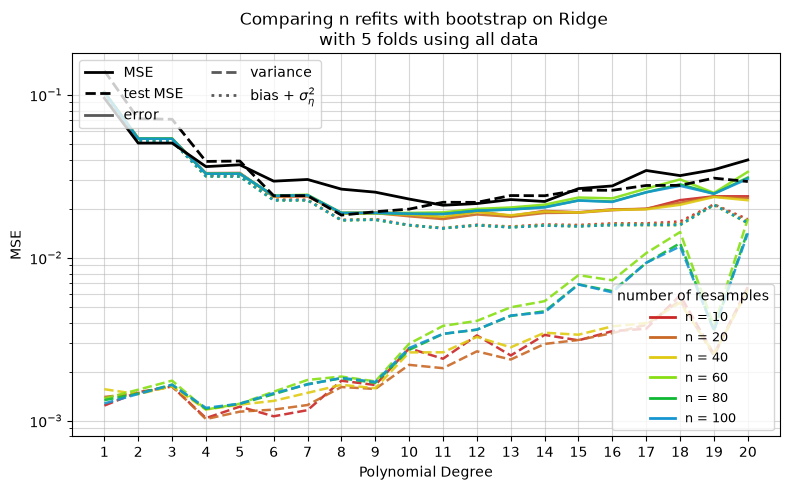

In [33]:
plot_mse_decomposition(results, model_shorthands, 0,  method = 'bootstrap_resampling', test_wholedataset= True)

ridge folds = 5


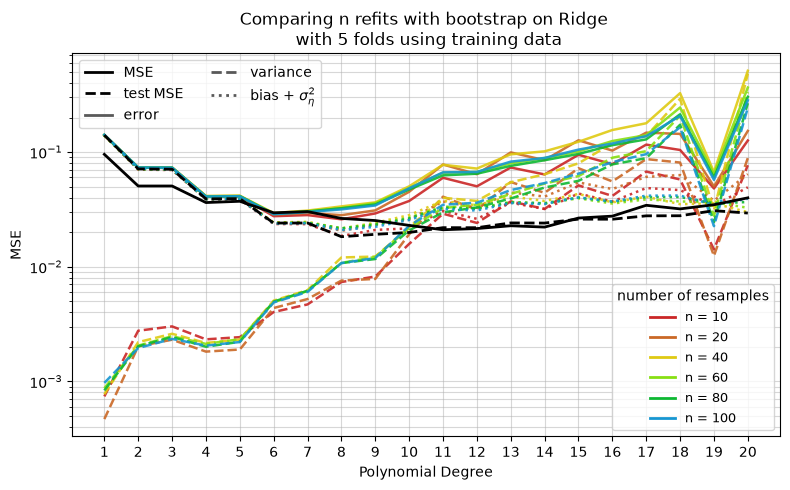

In [38]:
plot_mse_decomposition(results, model_shorthands, 0,  method = 'bootstrap_resampling', test_wholedataset= False)

### Kfold resampling MSE decomposition

ridge folds = 5


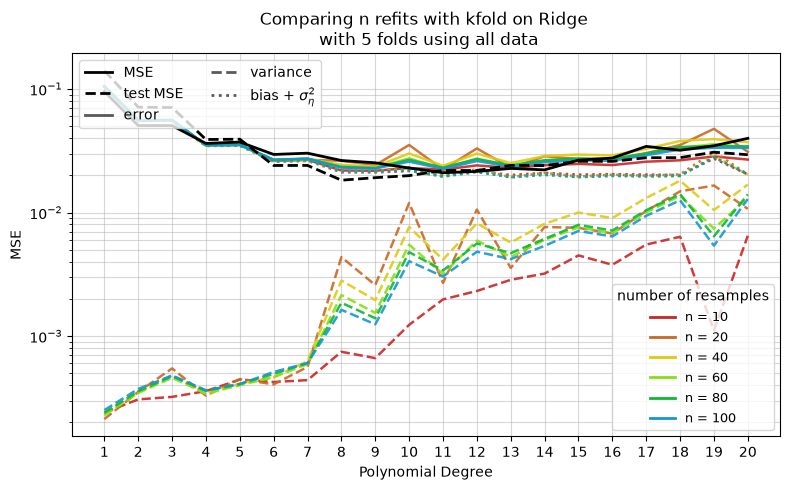

In [39]:
plot_mse_decomposition(results, model_shorthands, 0, test_wholedataset= True)

ridge folds = 5


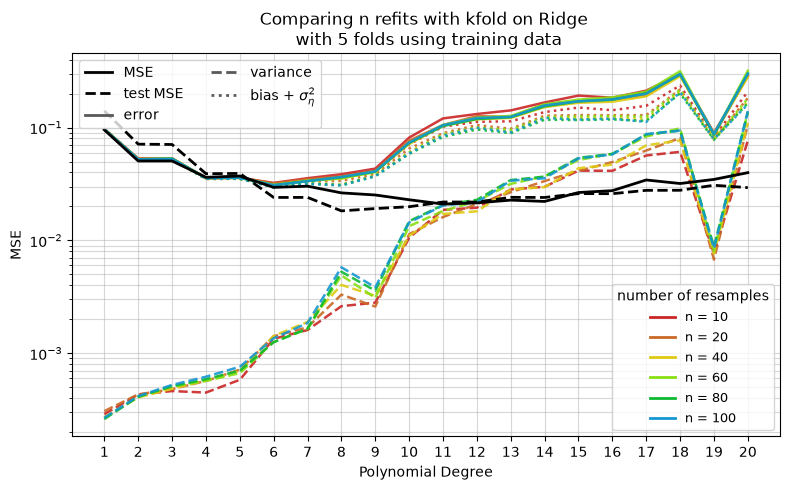

In [37]:
plot_mse_decomposition(results, model_shorthands, 0, test_wholedataset= False)


Both forms of MSE decomposition when training data is used is equally terrible.